# 02 — Exploration des données formattées (Yahoo Finance)

Lecture du fichier `formatted/yahoofinance/wti.parquet` depuis S3 (LocalStack) pour vérifier le résultat du script `clean_yfinance.py`.

In [2]:
import io
import os
import boto3
import pandas as pd

# ── Connexion S3 LocalStack ──
os.environ["AWS_ACCESS_KEY_ID"] = "test"
os.environ["AWS_SECRET_ACCESS_KEY"] = "test"
os.environ["AWS_DEFAULT_REGION"] = "eu-west-1"

s3 = boto3.client("s3", endpoint_url="http://localhost:4566")

# ── Lecture du parquet formatté (dossier Spark) ──
# Spark écrit un dossier wti.parquet/ contenant _SUCCESS + part-*.parquet
prefix = "formatted/yahoofinance/wti.parquet/"
objs = s3.list_objects_v2(Bucket="datalake", Prefix=prefix)
parquet_key = [o["Key"] for o in objs.get("Contents", []) if o["Key"].endswith(".parquet")][0]

response = s3.get_object(Bucket="datalake", Key=parquet_key)
df = pd.read_parquet(io.BytesIO(response["Body"].read()), engine="pyarrow")

print(f"Shape : {df.shape[0]} lignes × {df.shape[1]} colonnes")
print(f"\nTypes :\n{df.dtypes}")
print(f"\nPlage : {df['Datetime'].min()} → {df['Datetime'].max()}")
df.head()

Shape : 460 lignes × 6 colonnes

Types :
Datetime    datetime64[ns]
Close              float64
High               float64
Low                float64
Open               float64
Volume               int64
dtype: object

Plage : 2026-02-19 05:00:00 → 2026-02-26 04:45:00


,Datetime,Close,High,Low,Open,Volume
0,2026-02-19 05:00:00,65.290001,65.309998,65.220001,65.220001,251
1,2026-02-19 05:15:00,65.260002,65.320000,65.230003,65.290001,422
2,2026-02-19 05:30:00,65.220001,65.269997,65.199997,65.269997,431
3,2026-02-19 05:45:00,65.230003,65.239998,65.190002,65.220001,235
4,2026-02-19 06:00:00,65.220001,65.260002,65.190002,65.239998,223


In [3]:
# ── Vérification qualité ──
print("Valeurs manquantes :")
print(df.isnull().sum())
print(f"\nDoublons sur Datetime : {df.duplicated(subset=['Datetime']).sum()}")
print(f"\nStatistiques :")
df.describe().round(2)

Valeurs manquantes :
Datetime    0
Close       0
High        0
Low         0
Open        0
Volume      0
dtype: int64

Doublons sur Datetime : 0

Statistiques :


,Datetime,Close,High,Low,Open,Volume
count,460,460.00,460.00,460.00,460.00,460.00
mean,2026-02-22 23:56:24.782608640,66.16,66.24,66.06,66.15,3401.05
min,2026-02-19 05:00:00,65.19,65.23,65.12,65.18,70.00
25%,2026-02-20 10:41:15,65.87,65.96,65.76,65.87,751.25
50%,2026-02-23 16:22:30,66.17,66.27,66.06,66.17,1674.50
75%,2026-02-24 23:03:45,66.46,66.56,66.35,66.46,4581.25
max,2026-02-26 04:45:00,67.24,67.28,67.12,67.25,46560.00
std,NaN,0.42,0.42,0.42,0.42,4426.01


In [4]:
# ── Aperçu dernières lignes ──
print("Dernières lignes :")
df.tail(50)

Dernières lignes :


,Datetime,Close,High,Low,Open,Volume
410,2026-02-25 15:30:00,65.459999,65.559998,65.260002,65.529999,17185
411,2026-02-25 15:45:00,65.410004,65.550003,65.250000,65.480003,13730
412,2026-02-25 16:00:00,65.330002,65.459999,65.120003,65.410004,10093
413,2026-02-25 16:15:00,65.510002,65.550003,65.250000,65.320000,7398
414,2026-02-25 16:30:00,65.330002,65.550003,65.309998,65.519997,7212
415,2026-02-25 16:45:00,65.459999,65.480003,65.290001,65.339996,4819
416,2026-02-25 17:00:00,65.470001,65.529999,65.339996,65.459999,5830
417,2026-02-25 17:15:00,65.510002,65.540001,65.440002,65.480003,3371
418,2026-02-25 17:30:00,65.440002,65.529999,65.419998,65.500000,2767
419,2026-02-25 17:45:00,65.529999,65.570000,65.389999,65.440002,3573


---
# Exploration des données formattées (GDELT)

Lecture du fichier `formatted/gdelt/events.parquet` depuis S3 (LocalStack) pour vérifier le résultat du script `clean_gdelt.py`.

In [5]:
# ═══════════════════════════════════════════════
# Chargement du Parquet formatté GDELT depuis S3
# ═══════════════════════════════════════════════
prefix_gdelt = "formatted/gdelt/events.parquet/"
objs_gdelt = s3.list_objects_v2(Bucket="datalake", Prefix=prefix_gdelt)
parquet_keys_gdelt = [o["Key"] for o in objs_gdelt.get("Contents", []) if o["Key"].endswith(".parquet")]

# Spark peut écrire plusieurs partitions → on les concat
dfs = []
for key in parquet_keys_gdelt:
    response = s3.get_object(Bucket="datalake", Key=key)
    dfs.append(pd.read_parquet(io.BytesIO(response["Body"].read()), engine="pyarrow"))

df_gdelt = pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()

print(f"Shape : {df_gdelt.shape[0]} lignes × {df_gdelt.shape[1]} colonnes")
print(f"\nTypes :\n{df_gdelt.dtypes}")
print(f"\nColonnes : {list(df_gdelt.columns)}")
df_gdelt.head()

Shape : 834984 lignes × 23 colonnes

Types :
GlobalEventID                     int64
Day                              object
DATEADDED                datetime64[ns]
Actor1Code                       object
Actor1Name                       object
Actor1CountryCode                object
Actor1Type1Code                  object
Actor2Code                       object
Actor2Name                       object
Actor2CountryCode                object
Actor2Type1Code                  object
EventCode                         int32
EventRootCode                     int32
QuadClass                         int32
GoldsteinScale                  float64
IsRootEvent                       int32
ActionGeo_CountryCode            object
ActionGeo_Lat                   float64
ActionGeo_Long                  float64
NumMentions                       int32
NumSources                        int32
NumArticles                       int32
AvgTone                         float64
dtype: object

Colonnes : ['GlobalE

,GlobalEventID,Day,DATEADDED,Actor1Code,Actor1Name,Actor1CountryCode,Actor1Type1Code,Actor2Code,Actor2Name,Actor2CountryCode,...,QuadClass,GoldsteinScale,IsRootEvent,ActionGeo_CountryCode,ActionGeo_Lat,ActionGeo_Long,NumMentions,NumSources,NumArticles,AvgTone
0,1289876162,2025-02-19,2026-02-18 23:00:00,None,None,None,None,EDU,ECONOMIST,None,...,2,6.4,1,US,38.8951,-77.0364,2,1,2,-2.099738
1,1289876163,2025-02-19,2026-02-18 23:00:00,None,None,None,None,EDU,ECONOMIST,None,...,2,6.4,1,US,42.1497,-74.9384,8,2,8,-1.852742
2,1289876165,2025-02-19,2026-02-18 23:00:00,CHR,CHRISTIAN,None,None,ECU,ECUADOR,ECU,...,4,-5.0,1,US,41.5834,-72.7622,3,1,3,-6.744868
3,1289876171,2025-02-19,2026-02-18 23:00:00,MIL,COAST GUARD,None,MIL,None,None,None,...,2,7.4,0,US,39.0724,-76.7902,10,2,10,-3.282828
4,1289876172,2025-02-19,2026-02-18 23:00:00,MIL,NAVY,None,MIL,MED,WEBSITE,None,...,3,-2.0,1,US,38.8951,-77.0364,10,1,10,0.777778


In [6]:
# ═══════════════════════════════════════════════
# Statistiques descriptives GDELT
# ═══════════════════════════════════════════════
print("Valeurs manquantes :")
print(df_gdelt.isnull().sum())
print(f"\nDoublons sur GlobalEventID : {df_gdelt.duplicated(subset=['GlobalEventID']).sum()}")
print(f"\nPlage temporelle : {df_gdelt['DATEADDED'].min()} → {df_gdelt['DATEADDED'].max()}")
print(f"\nStatistiques numériques :")
df_gdelt.describe().round(2)

Valeurs manquantes :
GlobalEventID                 0
Day                           0
DATEADDED                     0
Actor1Code                79668
Actor1Name                79668
Actor1CountryCode        365863
Actor1Type1Code          469898
Actor2Code               244274
Actor2Name               244274
Actor2CountryCode        468424
Actor2Type1Code          553925
EventCode                     0
EventRootCode                 0
QuadClass                     0
GoldsteinScale                1
IsRootEvent                   0
ActionGeo_CountryCode     23238
ActionGeo_Lat             23529
ActionGeo_Long            23390
NumMentions                   0
NumSources                    0
NumArticles                   0
AvgTone                       0
dtype: int64

Doublons sur GlobalEventID : 0

Plage temporelle : 2026-02-18 23:00:00 → 2026-02-26 11:30:00

Statistiques numériques :


,GlobalEventID,DATEADDED,EventCode,EventRootCode,QuadClass,GoldsteinScale,IsRootEvent,ActionGeo_Lat,ActionGeo_Long,NumMentions,NumSources,NumArticles,AvgTone
count,8.349840e+05,834984,834984.00,834984.00,834984.00,834983.00,834984.00,811455.00,811594.00,834984.00,834984.00,834984.00,834984.00
mean,1.290518e+09,2026-02-22 19:22:47.153142272,95.55,6.75,1.79,0.52,0.56,31.31,-8.05,4.67,1.04,4.56,-1.91
min,1.289876e+09,2026-02-18 23:00:00,10.00,1.00,1.00,-10.00,0.00,-85.62,-179.77,1.00,1.00,1.00,-31.25
25%,1.290192e+09,2026-02-20 14:00:00,36.00,3.00,1.00,-2.00,0.00,25.09,-81.72,2.00,1.00,2.00,-4.58
50%,1.290520e+09,2026-02-23 05:30:00,46.00,4.00,1.00,1.00,1.00,35.75,0.12,4.00,1.00,4.00,-1.87
75%,1.290846e+09,2026-02-24 20:15:00,111.00,11.00,3.00,3.40,1.00,43.01,47.50,6.00,1.00,6.00,0.84
max,1.291162e+09,2026-02-26 11:30:00,1832.00,20.00,4.00,10.00,1.00,81.50,180.00,710.00,22.00,340.00,25.49
std,3.741319e+05,NaN,182.57,5.50,1.12,4.62,0.50,20.55,78.89,4.43,0.39,3.99,4.16


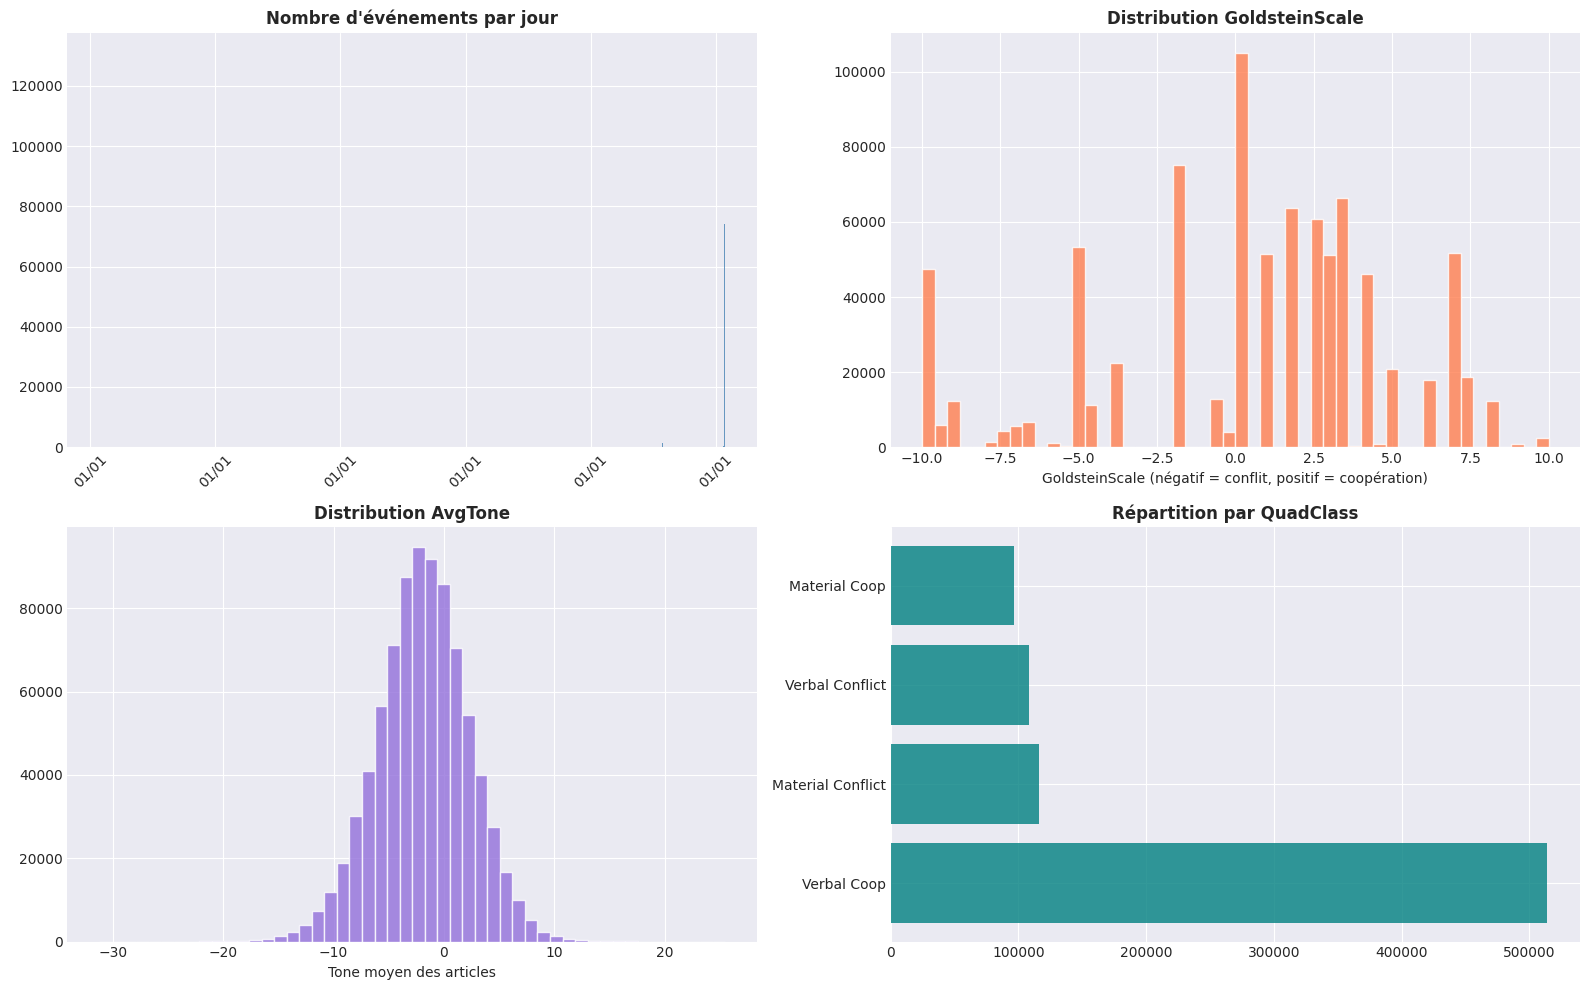

In [7]:
# ═══════════════════════════════════════════════
# Distribution des événements GDELT
# ═══════════════════════════════════════════════
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.style.use("seaborn-v0_8-darkgrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Nombre d'événements par jour
if "Day" in df_gdelt.columns:
    df_gdelt["Day_dt"] = pd.to_datetime(df_gdelt["Day"], format="%Y%m%d", errors="coerce")
    daily = df_gdelt.groupby("Day_dt").size()
    axes[0, 0].bar(daily.index, daily.values, color="steelblue", alpha=0.8)
    axes[0, 0].set_title("Nombre d'événements par jour", fontweight="bold")
    axes[0, 0].xaxis.set_major_formatter(mdates.DateFormatter("%d/%m"))
    axes[0, 0].tick_params(axis="x", rotation=45)

# 2. Distribution GoldsteinScale
if "GoldsteinScale" in df_gdelt.columns:
    axes[0, 1].hist(df_gdelt["GoldsteinScale"].dropna(), bins=50, color="coral", alpha=0.8, edgecolor="white")
    axes[0, 1].set_title("Distribution GoldsteinScale", fontweight="bold")
    axes[0, 1].set_xlabel("GoldsteinScale (négatif = conflit, positif = coopération)")

# 3. Distribution AvgTone
if "AvgTone" in df_gdelt.columns:
    axes[1, 0].hist(df_gdelt["AvgTone"].dropna(), bins=50, color="mediumpurple", alpha=0.8, edgecolor="white")
    axes[1, 0].set_title("Distribution AvgTone", fontweight="bold")
    axes[1, 0].set_xlabel("Tone moyen des articles")

# 4. Top 10 QuadClass
if "QuadClass" in df_gdelt.columns:
    top_quad = df_gdelt["QuadClass"].value_counts().head(10)
    quad_labels = {1: "Verbal Coop", 2: "Material Coop", 3: "Verbal Conflict", 4: "Material Conflict"}
    top_quad.index = [quad_labels.get(int(x), str(x)) for x in top_quad.index]
    axes[1, 1].barh(top_quad.index, top_quad.values, color="teal", alpha=0.8)
    axes[1, 1].set_title("Répartition par QuadClass", fontweight="bold")

plt.tight_layout()
plt.show()

In [8]:
# ═══════════════════════════════════════════════
# Aperçu dernières lignes GDELT
# ═══════════════════════════════════════════════
print(f"Dernières lignes :")
df_gdelt.tail(200)

Dernières lignes :


,GlobalEventID,Day,DATEADDED,Actor1Code,Actor1Name,Actor1CountryCode,Actor1Type1Code,Actor2Code,Actor2Name,Actor2CountryCode,...,GoldsteinScale,IsRootEvent,ActionGeo_CountryCode,ActionGeo_Lat,ActionGeo_Long,NumMentions,NumSources,NumArticles,AvgTone,Day_dt
834784,1291160905,2026-02-26,2026-02-26 11:30:00,GBR,UNITED KINGDOM,GBR,None,BGD,BANGLADESH,BGD,...,0.0,1,BG,24.8967,91.871700,2,1,2,4.641350,2026-02-26
834785,1291160907,2026-02-26,2026-02-26 11:30:00,GBR,UNITED KINGDOM,GBR,None,BGD,BANGLADESH,BGD,...,0.0,1,UK,54.0000,-4.000000,3,1,3,4.641350,2026-02-26
834786,1291160915,2026-02-26,2026-02-26 11:30:00,GBR,BRITISH,GBR,None,GOV,GOVERNMENT,None,...,-2.0,1,UK,52.8333,0.516667,1,1,1,-1.795841,2026-02-26
834787,1291160917,2026-02-26,2026-02-26 11:30:00,GBR,BRITISH,GBR,None,LEG,REPRESENTATIVES,None,...,3.4,1,UK,54.0000,-4.000000,2,1,2,4.641350,2026-02-26
834788,1291160922,2026-02-26,2026-02-26 11:30:00,GBRCOP,UNITED KINGDOM,GBR,COP,CRM,CRIMINAL,None,...,-2.0,0,UK,51.5000,-0.116667,10,1,10,-1.795841,2026-02-26
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
834979,1291161600,2026-02-26,2026-02-26 11:30:00,USAMED,UNITED STATES,USA,MED,MED,MEDIA,None,...,1.9,0,US,38.8951,-77.036400,8,1,8,-1.779359,2026-02-26
834980,1291161604,2026-02-26,2026-02-26 11:30:00,USAMIL,THE US,USA,MIL,MIL,AIR FORCE,None,...,1.9,0,CH,39.9289,116.388000,1,1,1,-2.338129,2026-02-26
834981,1291161607,2026-02-26,2026-02-26 11:30:00,VEN,VENEZUELA,VEN,None,IRN,IRAN,IRN,...,3.0,1,CH,35.0000,105.000000,2,1,2,-2.415813,2026-02-26
834982,1291161610,2026-02-26,2026-02-26 11:30:00,ZAFGOV,SOUTH AFRICAN,ZAF,GOV,UKR,UKRAINE,UKR,...,-0.4,1,SF,-30.0000,26.000000,1,1,1,-2.526316,2026-02-26


In [9]:
# ═══════════════════════════════════════════════
# Affichage des 20 premières lignes GDELT
# ═══════════════════════════════════════════════
df_gdelt.head(100)

,GlobalEventID,Day,DATEADDED,Actor1Code,Actor1Name,Actor1CountryCode,Actor1Type1Code,Actor2Code,Actor2Name,Actor2CountryCode,...,GoldsteinScale,IsRootEvent,ActionGeo_CountryCode,ActionGeo_Lat,ActionGeo_Long,NumMentions,NumSources,NumArticles,AvgTone,Day_dt
0,1289876162,2025-02-19,2026-02-18 23:00:00,None,None,None,None,EDU,ECONOMIST,None,...,6.4,1,US,38.8951,-77.0364,2,1,2,-2.099738,2025-02-19
1,1289876163,2025-02-19,2026-02-18 23:00:00,None,None,None,None,EDU,ECONOMIST,None,...,6.4,1,US,42.1497,-74.9384,8,2,8,-1.852742,2025-02-19
2,1289876165,2025-02-19,2026-02-18 23:00:00,CHR,CHRISTIAN,None,None,ECU,ECUADOR,ECU,...,-5.0,1,US,41.5834,-72.7622,3,1,3,-6.744868,2025-02-19
3,1289876171,2025-02-19,2026-02-18 23:00:00,MIL,COAST GUARD,None,MIL,None,None,None,...,7.4,0,US,39.0724,-76.7902,10,2,10,-3.282828,2025-02-19
4,1289876172,2025-02-19,2026-02-18 23:00:00,MIL,NAVY,None,MIL,MED,WEBSITE,None,...,-2.0,1,US,38.8951,-77.0364,10,1,10,0.777778,2025-02-19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,1289876543,2026-02-19,2026-02-18 23:00:00,None,None,None,None,USAMIL,PENNSYLVANIA,USA,...,7.0,1,US,46.2502,-94.2506,20,2,20,-6.666667,2026-02-19
96,1289876549,2026-02-19,2026-02-18 23:00:00,AFR,AFRICA,AFR,None,None,None,None,...,-10.0,0,SF,-29.8031,31.0310,6,1,6,-7.246377,2026-02-19
97,1289876550,2026-02-19,2026-02-18 23:00:00,AFR,AFRICA,AFR,None,None,None,None,...,-10.0,0,SF,-29.8031,31.0310,2,1,2,-7.246377,2026-02-19
98,1289876553,2026-02-19,2026-02-18 23:00:00,AGR,FISHER,None,AGR,None,None,None,...,4.0,1,US,34.0633,-118.3590,2,1,2,4.134367,2026-02-19


In [10]:
print(df_gdelt.iloc[110])

GlobalEventID                     1289876588
Day                               2026-02-19
DATEADDED                2026-02-18 23:00:00
Actor1Code                               AUS
Actor1Name                          VICTORIA
Actor1CountryCode                        AUS
Actor1Type1Code                         None
Actor2Code                              None
Actor2Name                              None
Actor2CountryCode                       None
Actor2Type1Code                         None
EventCode                                 71
EventRootCode                              7
QuadClass                                  2
GoldsteinScale                           7.4
IsRootEvent                                1
ActionGeo_CountryCode                   None
ActionGeo_Lat                            NaN
ActionGeo_Long                           NaN
NumMentions                                5
NumSources                                 1
NumArticles                                5
AvgTone   

In [11]:
# Filtrer les lignes avec OPC en Actor1Code ou Actor2Code
df_opc = df_gdelt[(df_gdelt['Actor1Code'] == 'GOVOPC') | (df_gdelt['Actor2Code'] == 'GOVOPC')]

print(f"Nombre de lignes avec OPC : {len(df_opc)}")
df_opc.head(50)

Nombre de lignes avec OPC : 0


,GlobalEventID,Day,DATEADDED,Actor1Code,Actor1Name,Actor1CountryCode,Actor1Type1Code,Actor2Code,Actor2Name,Actor2CountryCode,...,GoldsteinScale,IsRootEvent,ActionGeo_CountryCode,ActionGeo_Lat,ActionGeo_Long,NumMentions,NumSources,NumArticles,AvgTone,Day_dt


In [16]:
import numpy as np

# ═══════════════════════════════════════════════
# Ajout des colonnes "buzz" et "gravité pondérée"
# ═══════════════════════════════════════════════


# Création d'une copie du dataset filtré pour ajouter les nouvelles colonnes
df_gdelt_enriched = filter_all.copy()

# Calcul de "Le buzz" : log(1 + NumArticles)
df_gdelt_enriched['buzz'] = np.log(1 + df_gdelt_enriched['NumArticles'])

# Calcul de "La Gravité pondérée" : (10 - Goldstein) × (1 + (100 - AvgTone) / 50)
df_gdelt_enriched['gravite_ponderee'] = (
    (10 - df_gdelt_enriched['GoldsteinScale']) * 
    (1 + (100 - df_gdelt_enriched['AvgTone']) / 50)
)

print(f"✅ Nouvelles colonnes ajoutées : 'buzz' et 'gravite_ponderee'")
print(f"📊 Shape du dataset enrichi : {df_gdelt_enriched.shape[0]} lignes × {df_gdelt_enriched.shape[1]} colonnes\n")
print("=" * 150)
print("Aperçu des 100 premières lignes :\n")
df_gdelt_enriched.head(100)
df_gdelt_enriched.describe()


✅ Nouvelles colonnes ajoutées : 'buzz' et 'gravite_ponderee'
📊 Shape du dataset enrichi : 113930 lignes × 26 colonnes

Aperçu des 100 premières lignes :



,GlobalEventID,DATEADDED,EventCode,EventRootCode,QuadClass,GoldsteinScale,IsRootEvent,ActionGeo_Lat,ActionGeo_Long,NumMentions,NumSources,NumArticles,AvgTone,Day_dt,buzz,gravite_ponderee
count,1.139300e+05,113930,113930.000000,113930.000000,113930.000000,113930.000000,113930.000000,106477.000000,106503.000000,113930.000000,113930.000000,113930.000000,113930.000000,113930,113930.000000,113930.000000
mean,1.290519e+09,2026-02-22 19:33:44.040200448,214.736075,13.141894,3.130563,-2.185804,0.613780,30.988624,-9.948543,7.319407,1.073835,7.112692,-3.427336,2026-02-16 17:05:43.221276416,2.023503,37.623194
min,1.289876e+09,2026-02-18 23:00:00,60.000000,6.000000,2.000000,-10.000000,0.000000,-85.622100,-179.767000,4.000000,1.000000,4.000000,-31.250000,2016-02-22 00:00:00,1.609438,0.000000
25%,1.290197e+09,2026-02-20 14:30:00,80.000000,8.000000,2.000000,-9.000000,0.000000,24.513300,-83.648700,5.000000,1.000000,5.000000,-6.300268,2026-02-20 00:00:00,1.791759,10.896322
50%,1.290523e+09,2026-02-23 06:00:00,172.000000,15.000000,4.000000,-5.000000,1.000000,35.750000,-0.116667,6.000000,1.000000,6.000000,-3.382270,2026-02-23 00:00:00,1.945910,46.422805
75%,1.290846e+09,2026-02-24 20:15:00,190.000000,18.000000,4.000000,6.400000,1.000000,42.733400,48.514600,10.000000,1.000000,10.000000,-0.521410,2026-02-24 00:00:00,2.397895,59.197401
max,1.291162e+09,2026-02-26 11:30:00,1832.000000,20.000000,4.000000,10.000000,1.000000,81.500000,179.483000,310.000000,17.000000,310.000000,18.216319,2026-02-26 00:00:00,5.739793,71.500000
std,3.722289e+05,NaN,301.726597,5.134973,0.925561,7.132569,0.486884,20.582778,79.720882,4.622358,0.514984,4.205262,4.350769,NaN,0.350663,22.208340


In [24]:
# ═══════════════════════════════════════════════
# Analyse de l'impact des filtres avec EventRootCode
# ═══════════════════════════════════════════════

relevant_event_codes = [6, 8,10,11,12, 13, 14, 15, 16, 17, 18, 19, 20]

df_base = df_gdelt.copy()
total = len(df_base)

# Calcul de chaque filtre individuellement
f_eventroot = df_base['EventRootCode'].isin(relevant_event_codes)
f_numart    = df_base['NumArticles'] >= 4
f_goldstein = df_base['GoldsteinScale'].abs() >= 5
f_quadclass = df_base['QuadClass'] >= 2

# Construction du tableau d'impact
filters_summary = [
    ("Aucun filtre (données initiales)",                       total),
    ("EventRootCode ∈ liste",                                  f_eventroot.sum()),
    ("NumArticles >= 4",                                       f_numart.sum()),
    ("|GoldsteinScale| >= 5",                                  f_goldstein.sum()),
    ("QuadClass >= 2",                                         f_quadclass.sum()),
    ("EventRootCode ∈ liste ET NumArticles >= 4",              (f_eventroot & f_numart).sum()),
    ("EventRootCode ∈ liste ET |GoldsteinScale| >= 5",         (f_eventroot & f_goldstein).sum()),
    ("EventRootCode ∈ liste ET QuadClass >= 2",                (f_eventroot & f_quadclass).sum()),
    ("NumArticles >= 4 ET |GoldsteinScale| >= 5",              (f_numart & f_goldstein).sum()),
    ("NumArticles >= 4 ET QuadClass >= 2",                     (f_numart & f_quadclass).sum()),
    ("|GoldsteinScale| >= 5 ET QuadClass >= 2",                (f_goldstein & f_quadclass).sum()),
    ("TOUS LES FILTRES COMBINÉS",                              (f_numart & f_goldstein & f_quadclass).sum()),
]

results_extended = pd.DataFrame(filters_summary, columns=["Filtre(s) appliqué(s)", "Nombre de lignes"])
results_extended["% restant"]  = (results_extended["Nombre de lignes"] / total * 100).round(2)
results_extended["Lignes retirées"] = total - results_extended["Nombre de lignes"]
results_extended["% retiré"]   = (results_extended["Lignes retirées"] / total * 100).round(2)

print(f"Total initial : {total:,} lignes\n")
print(f"Codes EventRootCode conservés : {relevant_event_codes}\n")
display(results_extended)

# Aperçu du dataset final avec tous les filtres combinés
df_final = df_base[f_numart & f_goldstein & f_quadclass].copy()
print(f"\n✅ Dataset final (tous filtres) : {len(df_final):,} lignes × {df_final.shape[1]} colonnes")
df_final.head(20)

Total initial : 834,984 lignes

Codes EventRootCode conservés : [6, 8, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]



,Filtre(s) appliqué(s),Nombre de lignes,% restant,Lignes retirées,% retiré
0,Aucun filtre (données initiales),834984,100.00,0,0.00
1,EventRootCode ∈ liste,272589,32.65,562395,67.35
2,NumArticles >= 4,433590,51.93,401394,48.07
3,|GoldsteinScale| >= 5,263314,31.54,571670,68.46
4,QuadClass >= 2,320946,38.44,514038,61.56
5,EventRootCode ∈ liste ET NumArticles >= 4,143182,17.15,691802,82.85
6,EventRootCode ∈ liste ET |GoldsteinScale| >= 5,186041,22.28,648943,77.72
7,EventRootCode ∈ liste ET QuadClass >= 2,272589,32.65,562395,67.35
8,NumArticles >= 4 ET |GoldsteinScale| >= 5,138199,16.55,696785,83.45
9,NumArticles >= 4 ET QuadClass >= 2,171170,20.50,663814,79.50



✅ Dataset final (tous filtres) : 113,930 lignes × 24 colonnes


,GlobalEventID,Day,DATEADDED,Actor1Code,Actor1Name,Actor1CountryCode,Actor1Type1Code,Actor2Code,Actor2Name,Actor2CountryCode,...,GoldsteinScale,IsRootEvent,ActionGeo_CountryCode,ActionGeo_Lat,ActionGeo_Long,NumMentions,NumSources,NumArticles,AvgTone,Day_dt
1,1289876163,2025-02-19,2026-02-18 23:00:00,None,None,None,None,EDU,ECONOMIST,None,...,6.4,1,US,42.149700,-74.9384,8,2,8,-1.852742,2025-02-19
3,1289876171,2025-02-19,2026-02-18 23:00:00,MIL,COAST GUARD,None,MIL,None,None,None,...,7.4,0,US,39.072400,-76.7902,10,2,10,-3.282828,2025-02-19
5,1289876173,2025-02-19,2026-02-18 23:00:00,MNCUSA,MICROSOFT,USA,MNC,None,None,None,...,-10.0,1,IN,28.600000,77.2000,10,1,10,1.020408,2025-02-19
13,1289876199,2026-02-12,2026-02-18 23:00:00,LAB,EMPLOYEE,None,LAB,USA,UNITED STATES,USA,...,-5.0,1,US,34.098300,-118.3270,6,1,6,-2.110818,2026-02-12
15,1289876202,2026-02-12,2026-02-18 23:00:00,USACOP,ALABAMA,USA,COP,None,None,None,...,-10.0,1,US,33.266800,-86.6666,6,1,6,1.403509,2026-02-12
25,1289876245,2026-02-19,2026-02-18 23:00:00,None,None,None,None,CHRCTH,CATHOLIC,None,...,-5.0,1,EI,53.000000,-8.0000,6,1,6,-1.624815,2026-02-19
30,1289876260,2026-02-19,2026-02-18 23:00:00,None,None,None,None,COP,TROOPER,None,...,-5.0,1,US,32.799000,-86.8073,10,1,10,-7.729469,2026-02-19
50,1289876332,2026-02-19,2026-02-18 23:00:00,None,None,None,None,GOV,AUTHORITIES,None,...,7.0,1,US,34.852600,-82.3940,6,1,6,-6.682028,2026-02-19
57,1289876384,2026-02-19,2026-02-18 23:00:00,None,None,None,None,MED,WEBSITE,None,...,-10.0,0,US,45.732600,-93.9196,8,1,8,-7.777778,2026-02-19
83,1289876500,2026-02-19,2026-02-18 23:00:00,None,None,None,None,USA,UNITED STATES,USA,...,-5.0,1,US,36.170000,-119.7460,4,1,4,-1.920236,2026-02-19
